# ARC synthetic playground

Create ARC-style puzzles **together with their solutions** (a program of real grid operations), look at them,
build a mixed training set, train the small program-inference GPT, check what it learned, and combine it with search.

**Sections** 1 setup · 2 operation bank & task families · 3 look at puzzles + step-by-step solutions · 4 make your own family ·
5 build datasets · 6 train · 7 diagnose & evaluate · 8 model + search on real tasks

`QUICK = True` (default) runs everything end-to-end in a few minutes on CPU as a smoke test.
Set it to `False` for a real run (use a GPU runtime; see `docs/GPU_TRAINING.md` for the settings that fit an 8 GB card).

## 1. Setup

In [1]:
import os, sys, json, subprocess, pathlib, random, collections, time
if not pathlib.Path("arcgen").exists():                      # Colab / Kaggle: fetch the repo
    if not pathlib.Path("arc-agi-mini").exists():
        subprocess.run(["git", "clone", "-b", "claude/nifty-wright-ojo5du",
                        "https://github.com/RustamBB/arc-agi-mini"], check=True)
    os.chdir("arc-agi-mini")
sys.path.insert(0, os.getcwd()); sys.path.insert(0, os.path.join(os.getcwd(), "tools"))
import numpy as np
import matplotlib.pyplot as plt
import arcgen
from arcgen import OPS, generate, run
from arcgen.curated import FAMILIES, make_curated_task, st, S, New
from arcgen.dataset import record, task_id
from arcgen.program import to_text
from arcgen.viz import show_task, show_trace, show_pairs

QUICK = True                      # False = full-size run
DATA = pathlib.Path("data/nb"); DATA.mkdir(parents=True, exist_ok=True)
try:
    import torch; DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = None
print("operations:", len(OPS), "| task families:", len(FAMILIES), "| torch device:", DEVICE)

operations: 108 | task families: 33 | torch device: cpu


## 2. The operation bank and the hand-designed task families

In [2]:
by_cat = collections.defaultdict(list)
for name, op in OPS.items(): by_cat[op.category].append(name)
for cat, names in sorted(by_cat.items()):
    print(f"{cat:10s} ({len(names):2d}) " + ", ".join(sorted(names)))

color      (13) colors_by_frequency, dominant_color_cell, fill_bg, invert_binary, keep_color, majority_fill, recolor, recolor_all, recolor_by_frequency_rank, remove_color, shift_colors, swap_colors, swap_extreme_colors
geometry   (34) anti_transpose, concat_with, crop_fixed, crop_to_color, crop_to_content, dedupe_adjacent, draw_border, draw_grid_lines, extract_period, flip, fractal, half, half_logic, keep_center_line, mirror_concat, overlay_parts, pad, pad_replicate, pool, remove_border, rot90, rot_quad, scale_by_colors, scale_down, scale_up, self_logic, shear, symmetrize, symmetrize_bbox, take_part, tile, tile_flip, translate, transpose
line       ( 6) connect_diag, connect_pairs, fill_lines, full_lines, shoot_rays, stamp_shape
object     (31) bbox_fill, bbox_frame_all, copy_objects, count_bar_fixed, count_objects_bar, crop_object_only, crop_to_object, delete_objects, dilate, erode, fill_holes, flip_objects, frame_objects, gravity_cells, hollow_objects, keep_objects, majority_filter, 

In [3]:
print(f"{'family':24s} {'generator':12s} tags")
for f in FAMILIES.values():
    print(f"{f.name:24s} {f.gen:12s} {', '.join(f.tags)}")

family                   generator    tags
highlight_extract        objects      object, crop
odd_shape_out            shapes       object, relation
big_small_split          objects      object, classify
rank_and_fall            objects      object, physics
layer_slide_repaint      objects      color, physics
centres_only             objects      object, mark
isolate_crop_frame       objects      color, crop
denoise_then_fill        noisyrings   object, fill
clean_dots_halo          dotted       object, relation
majority_clean_shrink    blocky_noise noise, scale
marker_paint_halo        markers      relation
container_border         containers   relation
fly_to_wall_glow         attract      relation, physics
wire_to_wall             attract      relation, line
stamp_and_crop           template     relation, crop
flood_rooms_keep         seeded       relation, fill
box_then_flood           corners      relation, fill
crossing_lines           few          line
wires_with_halo          a

## 3. Look at puzzles and their solutions
Each family is a *story* whose steps depend on each other (a colour created in step 1 is the selector of step 2).
Change `FAMILY` / `INDEX` to browse. The title shows the English story and the program that solves it.

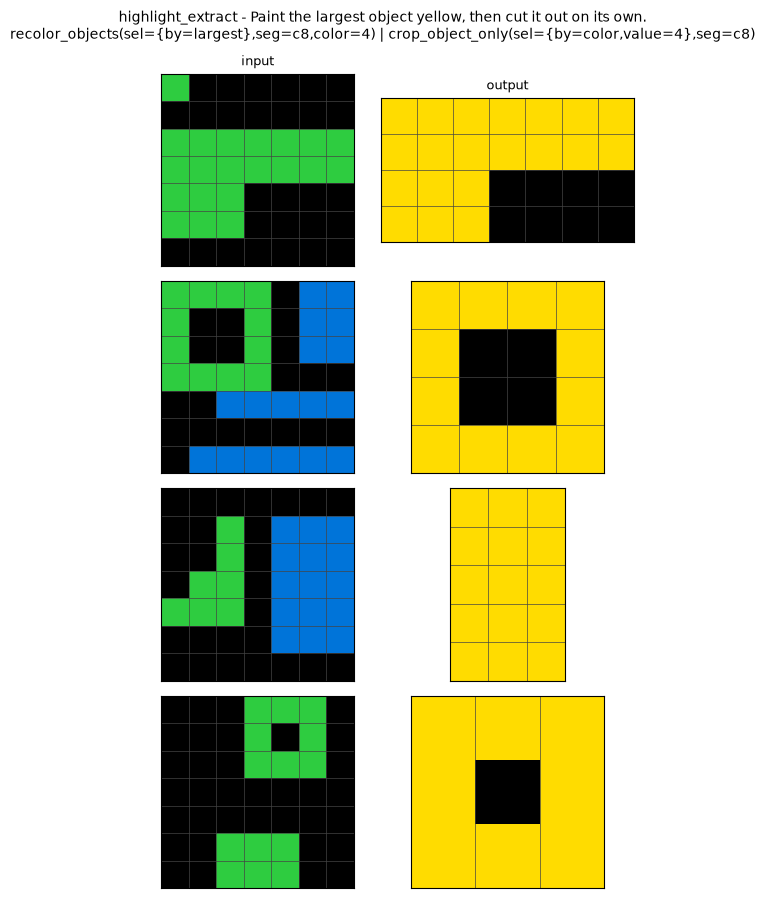

Paint the largest object yellow, then cut it out on its own.
recolor_objects(sel={by=largest},seg=c8,color=4) | crop_object_only(sel={by=color,value=4},seg=c8)


In [4]:
FAMILY, INDEX = "highlight_extract", 0          # try: denoise_then_fill, rank_and_fall, carpet_motif, patch_zoom ...
task = make_curated_task(seed=1, index=INDEX, names=[FAMILY])
rec = record(task, task_id(task), with_trace=False)
fig = show_task(rec); plt.show()
print(rec["story"]); print(rec["program_text"])

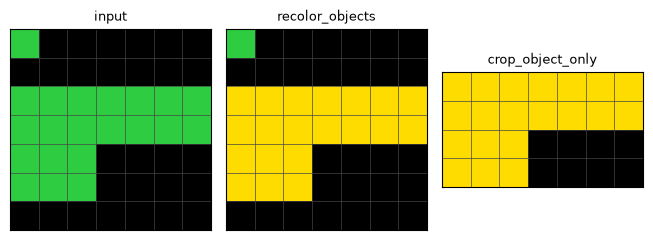

In [5]:
# step-by-step: intermediate grids of the first training input
grids = run(task.program, task.train[0][0])
fig = show_trace(grids, ["input"] + [s["op"] for s in task.program]); plt.show()

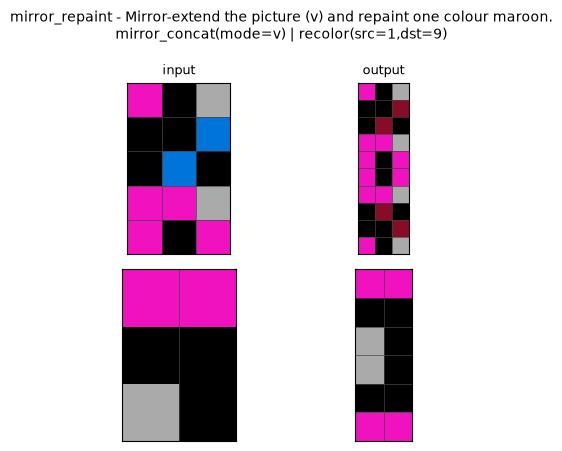

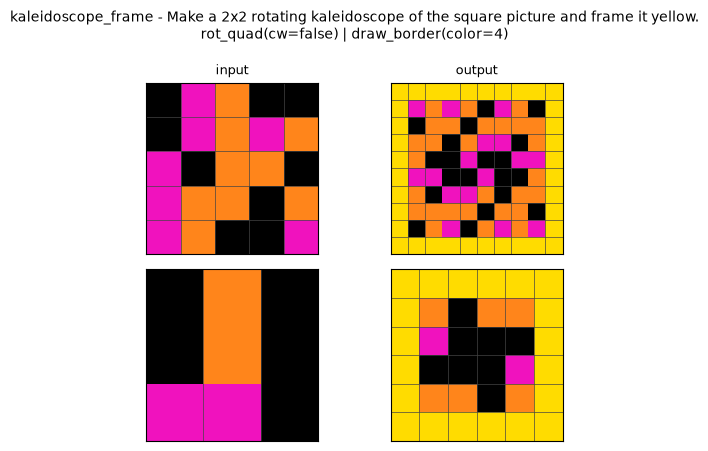

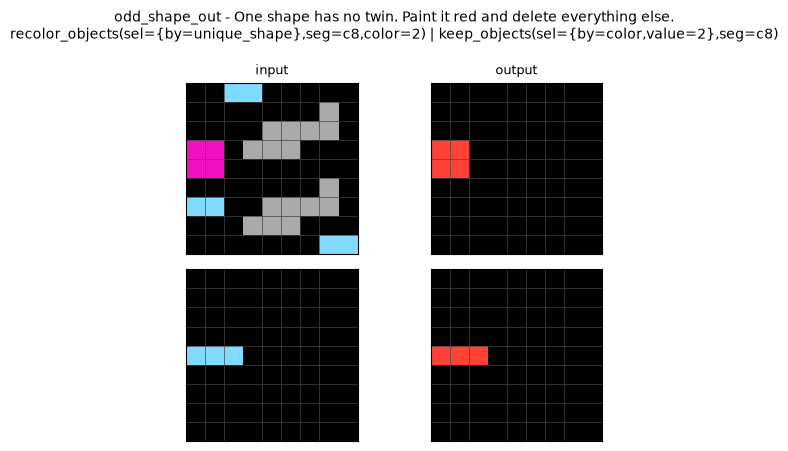

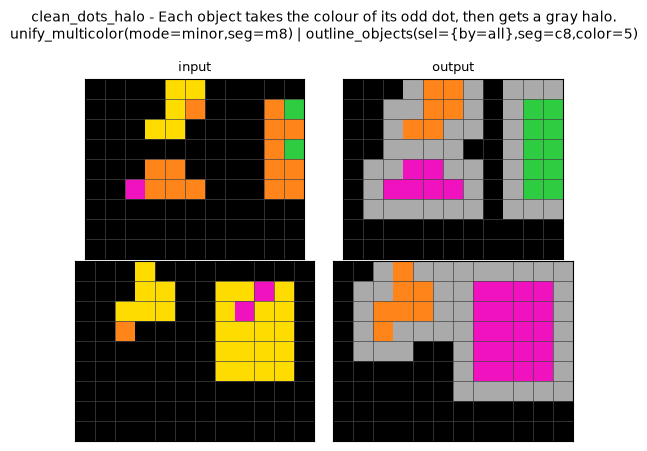

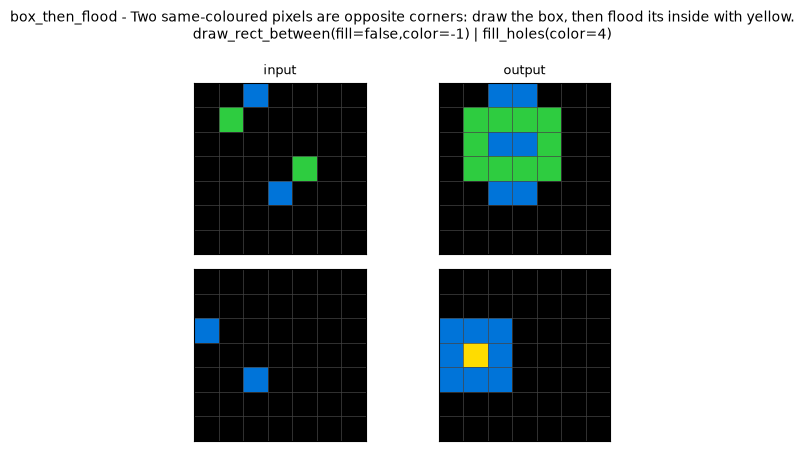

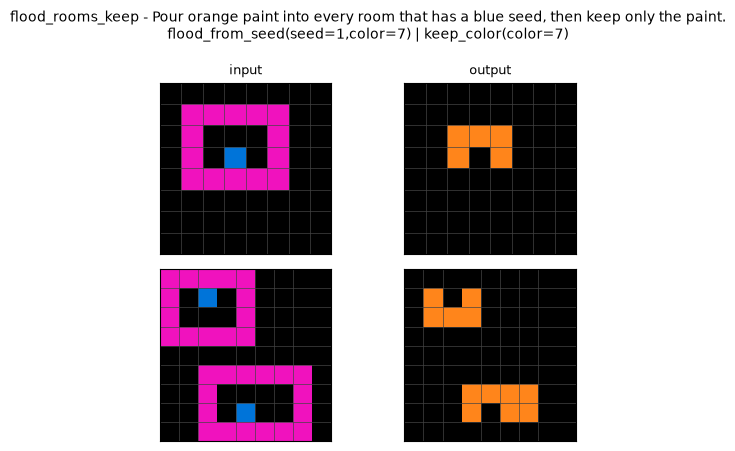

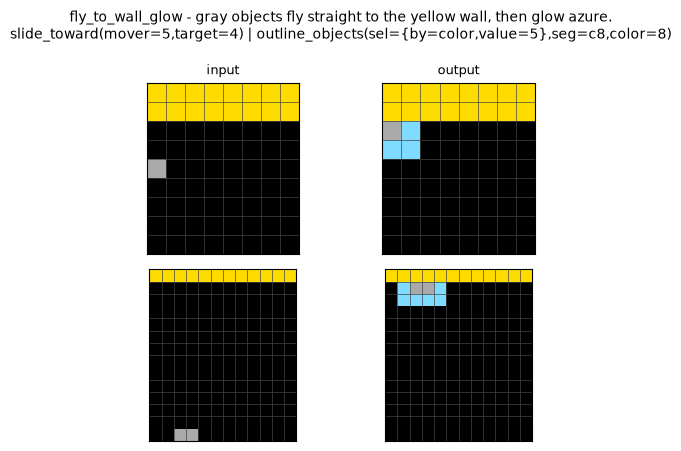

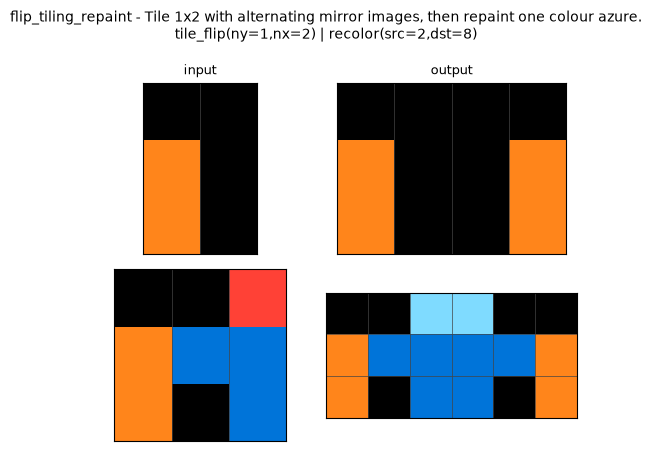

In [6]:
# a gallery: one puzzle from each of 8 different families
for i, name in enumerate(random.Random(0).sample(list(FAMILIES), 8)):
    t = make_curated_task(2, i, [name]); r = record(t, task_id(t), False)
    show_task(r, max_pairs=2); plt.show()

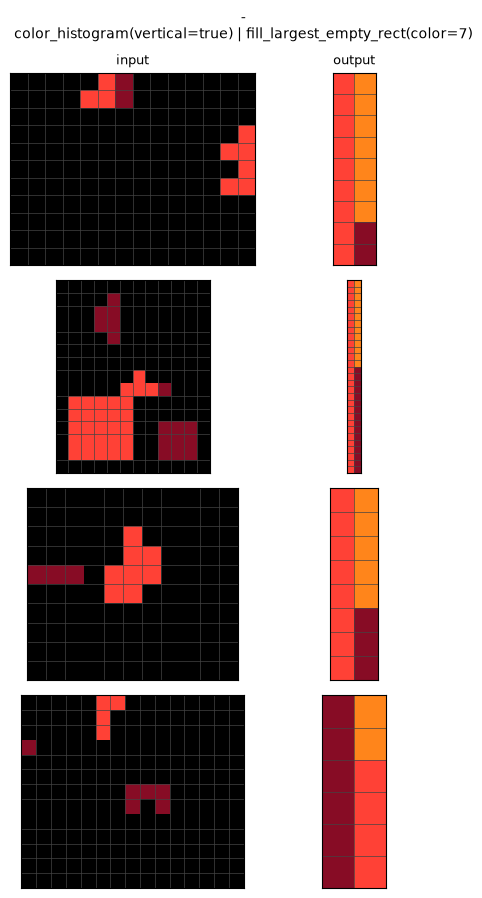

color_histogram(vertical=true) | fill_largest_empty_rect(color=7)


In [7]:
# random op-sampled puzzles (the other generator): less story, much more variety
from arcgen.dataset import make_task, resolve_ops
t = make_task(seed=3, index=0, op_pool=resolve_ops(), min_len=2, max_len=3)
r = record(t, task_id(t), False); show_task(r); plt.show(); print(r["program_text"])

## 4. Make your own family
A family = a program template + the name of an input generator. `New(rng, pal)` hands out colours that are *not* in the
input palette, so the output visibly introduces them. Run the cell, then check the puzzle makes sense; if it does, copy the
function into `arcgen/curated.py` with the `@family(...)` decorator to use it in datasets.

accepted


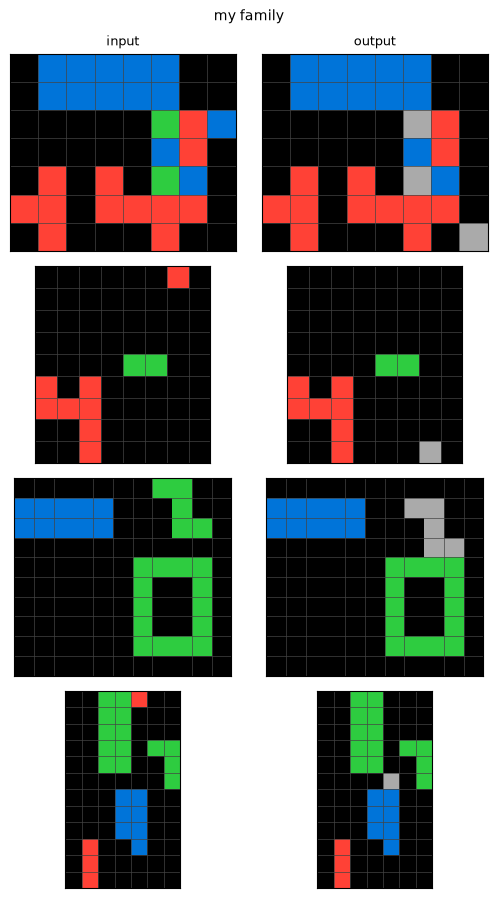

In [8]:
from arcgen.program import build_task
rng = np.random.default_rng(0)
pal = [1, 2, 3]; new = New(rng, pal); n = new()
my_steps = [st("recolor_objects", sel=S("smallest"), seg="c8", color=n),      # 1. paint the smallest object
            st("slide_objects", sel=S("color", n), seg="c8", dir="down")]     # 2. let the painted one fall
my_task = build_task(rng, my_steps, "objects", pal, lo=7, hi=12, n_train=3, n_test=1)
print("accepted" if my_task else "rejected (a step did nothing on most pairs, or outputs coincided)")
if my_task:
    show_pairs(my_task.train + my_task.test, "my family"); plt.show()

## 5. Build datasets (curated + random, mixed)

In [9]:
N_CUR, N_RND, N_VAL = (150, 150, 40) if QUICK else (60000, 60000, 1000)
def gen(kind, n, seed, name):
    out = DATA / name
    st_ = generate(n, str(out), seed=seed, kind=kind, arc_files=False, workers=1, log=lambda *_: None)
    return out / "dataset.jsonl", st_
t0 = time.time()
cur_path, cur_stats = gen("curated", N_CUR, 100, "curated")
rnd_path, rnd_stats = gen("random", N_RND, 101, "random")
val_path, _ = gen("mixed", N_VAL, 900, "val")                       # held-out, different seeds
lines = open(cur_path).read().splitlines() + open(rnd_path).read().splitlines()
random.Random(0).shuffle(lines)
open(DATA / "train.jsonl", "w").write("\n".join(lines) + "\n")
print(f"{len(lines)} training tasks written in {time.time()-t0:.0f}s ->", DATA / "train.jsonl")

300 training tasks written in 3s -> data/nb/train.jsonl


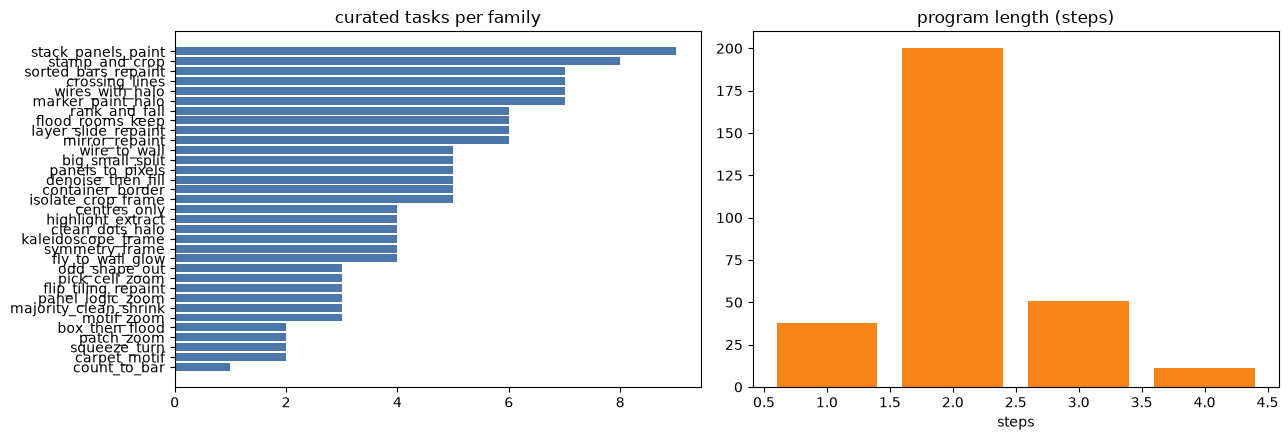

In [10]:
recs = [json.loads(l) for l in open(DATA / "train.jsonl")]
fam = collections.Counter(r["family"] for r in recs if "family" in r)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].barh(*zip(*sorted(fam.items(), key=lambda kv: kv[1])), color="#4c78a8"); ax[0].set_title("curated tasks per family")
ln = collections.Counter(len(r["ops"]) for r in recs)
ax[1].bar(ln.keys(), ln.values(), color="#f58518"); ax[1].set_title("program length (steps)"); ax[1].set_xlabel("steps")
plt.tight_layout(); plt.show()

## 6. Train the program-inference model
Input: demonstration pairs + a query; target: the program text. Defaults are tiny (smoke test).
For a real run set `QUICK = False`; on an 8 GB GPU use e.g. `D, LAYERS, HEADS, MAXLEN, BS, ACCUM = 384, 8, 6, 2048, 8, 4`, `--amp`, 40k steps.

In [11]:
if DEVICE is None:
    print("torch is not installed -> pip install torch")
else:
    D, LAYERS, HEADS, MAXLEN, BS, ACCUM = (128, 3, 4, 1024, 4, 1) if QUICK else (384, 8, 6, 2048, 8, 4)
    STEPS = 30 if QUICK else 40000
    cmd = [sys.executable, "tools/train_model.py", "--data", str(DATA / "train.jsonl"), "--val", str(val_path),
           "--out", str(DATA / "model.pt"), "--steps", str(STEPS), "--bs", str(BS), "--accum", str(ACCUM),
           "--d", str(D), "--layers", str(LAYERS), "--heads", str(HEADS), "--maxlen", str(MAXLEN),
           "--eval-every", str(max(10, STEPS // 4))] + (["--amp"] if DEVICE == "cuda" else [])
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout:
        if line.startswith(("step", "  val", "device", "[")) and (QUICK or line.split()[1].isdigit() and int(line.split()[1]) % 500 == 0 or "val" in line):
            print(line.rstrip())
    print("training finished, exit code", p.wait())

device cpu, amp False


  val token-acc 0.180


  val token-acc 0.184


step 25 loss 5.514 lr 9.62e-05 6s


  val token-acc 0.213


training finished, exit code 0


## 7. Diagnose and evaluate
`val token-acc` is dominated by trivial tokens (brackets, parameter names). The diagnosis below separates them from the
tokens that matter (operation names, numbers). Evaluation samples programs and **executes** them on the demonstrations.

In [12]:
r = subprocess.run([sys.executable, "tools/diagnose_model.py", "--model", str(DATA / "model.pt"), "--data", str(val_path),
                    "--n", "40" if QUICK else "300", "--device", DEVICE or "cpu"], capture_output=True, text=True)
print(r.stdout or r.stderr)

category                          tokens     acc  CE nats
punctuation                          537   0.404    3.602
param/enum name                      176   0.000    5.098
op name                               88   0.000    6.093
number (colour/size/offset)           82   0.000    4.992
enum value                            76   0.000    5.552
eos                                   40   0.000    3.902

first op token: model CE 6.155 nats, accuracy 0.000
                prior entropy of first op (ignores grids) 3.255 nats, most-common-op accuracy 0.075
-> model CE well below the prior entropy means the grids are being used; ~equal means they are not.



In [13]:
r = subprocess.run([sys.executable, "tools/eval_model.py", "--model", str(DATA / "model.pt"), "--synthetic", str(val_path),
                    "--n", "20" if QUICK else "300", "--samples", "8" if QUICK else "64", "--device", DEVICE or "cpu",
                    "--threads", "4"], capture_output=True, text=True)
print(r.stdout or r.stderr)

shard 0/1: 20 evaluated, 0 skipped (too long), 8s
  greedy_exact: 0.000
  greedy_train: 0.000
  train_verified: 0.000
  generalises: 0.000
  valid: 0.000



## 8. Model proposes, search disposes (hybrid)
Sample programs from the model for a held-out puzzle, then let `guided_solve` fix the operations the model suggested and
search their parameters. Point `REAL` to an ARC `*_challenges.json` to try real tasks.

In [14]:
from arcgen.model import Encoder, load
from eval_model import predict
from arcgen.guided import guided_solve
model, enc = load(str(DATA / "model.pt"), "cpu"), Encoder()
rec = json.loads(open(val_path).readline())
train = [(np.array(p["input"]), np.array(p["output"])) for p in rec["train"]]
test = [(np.array(p["input"]), np.array(p["output"])) for p in rec["test"]]
texts, _ = predict(model, enc, train, test[0][0], n=16 if QUICK else 64, temp=0.9)
print("true program   :", rec["program_text"]); print("model proposals:", *texts[:4], sep="\n    ")
prog, how = guided_solve(train, texts, budget=8 if QUICK else 30)
print("hybrid solution:", to_text(prog) if prog else None, f"({how})")

true program   : majority_filter(conn=4)
model proposals:
    )unify_multicolor yes recolor 9=slide_objects seg mover 4 connect_to_target,and right move_objects keep_objects scale_up value size_gt m4 pool id steps false shoot_rays | multicolor yes order no_hole 46 cells_to_pixels 4
    =[15 2 seg 2 rot180 transpose 16 | recolor_mirrored size_gt 7 40 leftmost not_rect symmetrize_bbox color_histogram full_lines 48
    all fill_bg colors=false b dl=7(dedupe_adjacent 2 v crop_fixed 4 k)corner -21 nor mode dominant_color_cell(==-5 keep_objects 57)recolor_all -7 swap any=(half_logic anti_transpose value recolor_split 0 recolor_contained==marker full_lines 1 overlay_parts keep_center_line recolor_from_marker 1 3 16 half_logic 6 -15 dilate rare_color repair_tiling h seed 9]=asc -5 scale_down hollow_objects 2 2 by),invert half dir 3 color marker color,-12 57 empty d4 down recolor_contained -1,]h


hybrid solution: None (None)


In [15]:
REAL = "arc-agi_training_challenges.json"      # path to a real ARC challenges file (optional)
if pathlib.Path(REAL).exists():
    d = json.load(open(REAL)); tid = list(d)[0]
    pairs = [(np.array(p["input"]), np.array(p["output"])) for p in d[tid]["train"]]
    texts, _ = predict(model, enc, pairs, np.array(d[tid]["test"][0]["input"]), n=32, temp=0.9)
    prog, how = guided_solve(pairs, texts or [], budget=20)
    print(tid, "->", to_text(prog) if prog else "not solved", how)
    show_pairs(pairs); plt.show()
else:
    print("set REAL to an ARC challenges json to try real tasks")

set REAL to an ARC challenges json to try real tasks
